In [1]:
from pathlib import Path
import tarfile
import urllib.request
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
DATA_ROOT.mkdir(exist_ok=True)
OUTPUT_ROOT.mkdir(exist_ok=True)

FRAMES_URL = "https://github.com/jchazalon/smartdoc15-ch1-dataset/releases/download/v2.0.0/frames.tar.gz"
ARCHIVE_PATH = DATA_ROOT / "frames.tar.gz"
EXTRACT_DIR = DATA_ROOT / "smartdoc_frames"

IMAGE_SIZE = 256
FRAME_STRIDE = 8
MAX_SAMPLES = 3000
VAL_SIZE = 0.2
BATCH_SIZE = 8 if torch.cuda.is_available() else 4
EPOCHS = 5
LEARNING_RATE = 1e-3
THRESHOLD = 0.5
FORCE_TRAIN = False
BEST_MODEL_PATH = OUTPUT_ROOT / "best_tiny_unet.pth"

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Output root:", OUTPUT_ROOT)

/Users/dinura.dissanayake/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Project root: /Users/dinura.dissanayake/Desktop/document_scanner_project
Data root: /Users/dinura.dissanayake/Desktop/document_scanner_project/data
Output root: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


In [2]:
def download_file(url: str, dest: Path):
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        print(f"Archive already exists: {dest}")
        return
    print(f"Downloading to {dest} ...")
    urllib.request.urlretrieve(url, dest)
    print("Download complete.")


def extract_tar_gz(archive_path: Path, extract_dir: Path):
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted_ok"
    if marker.exists():
        print(f"Archive already extracted: {extract_dir}")
        return
    print(f"Extracting {archive_path} ... this may take a few minutes.")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    marker.write_text("done", encoding="utf-8")
    print("Extraction complete.")


def find_metadata_file(root: Path) -> Path:
    candidates = list(root.rglob("metadata.csv.gz")) + list(root.rglob("metadata.csv"))
    if not candidates:
        raise FileNotFoundError("Could not find metadata.csv.gz or metadata.csv after extraction.")
    return candidates[0]


download_file(FRAMES_URL, ARCHIVE_PATH)
extract_tar_gz(ARCHIVE_PATH, EXTRACT_DIR)

METADATA_PATH = find_metadata_file(EXTRACT_DIR)
print("Metadata file:", METADATA_PATH)

if METADATA_PATH.suffix == ".gz":
    metadata = pd.read_csv(METADATA_PATH, compression="gzip")
else:
    metadata = pd.read_csv(METADATA_PATH)

print("Rows:", len(metadata))
display(metadata.head())

Archive already exists: /Users/dinura.dissanayake/Desktop/document_scanner_project/data/frames.tar.gz
Archive already extracted: /Users/dinura.dissanayake/Desktop/document_scanner_project/data/smartdoc_frames
Metadata file: /Users/dinura.dissanayake/Desktop/document_scanner_project/data/smartdoc_frames/metadata.csv.gz
Rows: 24889


,bg_name,bg_id,model_name,model_id,modeltype_name,modeltype_id,model_subid,image_path,frame_index,model_width,model_height,tl_x,tl_y,bl_x,bl_y,br_x,br_y,tr_x,tr_y
0,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0001.jpeg,1,2100.0,2970.0,698.087,200.476,692.141,891.077,1253.18,869.656,1178.15,191.515
1,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0002.jpeg,2,2100.0,2970.0,697.230,197.947,690.063,893.292,1254.61,871.689,1179.66,188.863
2,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0003.jpeg,3,2100.0,2970.0,694.344,197.669,693.706,885.112,1243.87,864.328,1176.90,188.845
3,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0004.jpeg,4,2100.0,2970.0,698.721,205.968,691.818,883.776,1240.73,862.179,1168.99,197.357
4,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0005.jpeg,5,2100.0,2970.0,696.853,205.898,690.721,883.791,1240.38,862.077,1167.82,196.579


In [3]:
metadata_sub = metadata[(metadata["frame_index"] - 1) % FRAME_STRIDE == 0].copy()
metadata_sub["session_id"] = metadata_sub["bg_name"].astype(str) + "_" + metadata_sub["model_name"].astype(str)

if len(metadata_sub) > MAX_SAMPLES:
    metadata_sub = metadata_sub.sample(n=MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
else:
    metadata_sub = metadata_sub.reset_index(drop=True)

print("Subsampled rows:", len(metadata_sub))
print("Unique sessions:", metadata_sub["session_id"].nunique())

splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(metadata_sub, groups=metadata_sub["session_id"]))

train_df = metadata_sub.iloc[train_idx].reset_index(drop=True)
val_df = metadata_sub.iloc[val_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Subsampled rows: 3000
Unique sessions: 150
Train size: 2406
Val size: 594


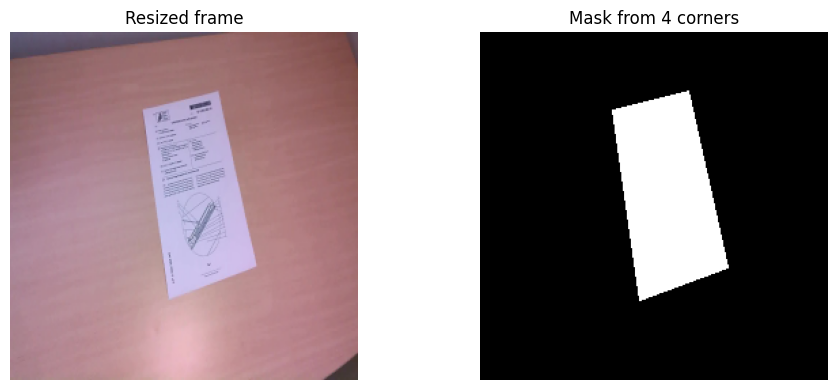

In [4]:
def read_rgb_image(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_quad_from_row(row):
    return np.array([
        [row["tl_x"], row["tl_y"]],
        [row["bl_x"], row["bl_y"]],
        [row["br_x"], row["br_y"]],
        [row["tr_x"], row["tr_y"]],
    ], dtype=np.float32)


def resize_quad(quad, orig_w, orig_h, target_w, target_h):
    sx = target_w / orig_w
    sy = target_h / orig_h
    quad_resized = quad.copy()
    quad_resized[:, 0] *= sx
    quad_resized[:, 1] *= sy
    return quad_resized


def quad_to_mask(quad, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    pts = np.round(quad).astype(np.int32)
    cv2.fillConvexPoly(mask, pts, 255)
    return mask


def show_image_and_mask(image, mask, title_image="Image", title_mask="Mask"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image)
    axes[0].set_title(title_image)
    axes[0].axis("off")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(title_mask)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


sample_row = train_df.sample(1, random_state=SEED).iloc[0]
sample_img_path = EXTRACT_DIR / sample_row["image_path"]
sample_image = read_rgb_image(sample_img_path)
h, w = sample_image.shape[:2]
sample_quad = get_quad_from_row(sample_row)
sample_quad_256 = resize_quad(sample_quad, w, h, IMAGE_SIZE, IMAGE_SIZE)
sample_image_256 = cv2.resize(sample_image, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
sample_mask_256 = quad_to_mask(sample_quad_256, IMAGE_SIZE, IMAGE_SIZE)

show_image_and_mask(sample_image_256, sample_mask_256, "Resized frame", "Mask from 4 corners")

In [5]:
class SmartDocSegmentationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root_dir: Path, image_size: int = 256):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.root_dir / row["image_path"]

        image = read_rgb_image(image_path)
        orig_h, orig_w = image.shape[:2]

        quad = get_quad_from_row(row)
        quad_resized = resize_quad(quad, orig_w, orig_h, self.image_size, self.image_size)

        image_resized = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = quad_to_mask(quad_resized, self.image_size, self.image_size)

        image_tensor = torch.from_numpy(image_resized).float().permute(2, 0, 1) / 255.0
        mask_tensor = torch.from_numpy(mask).float().unsqueeze(0) / 255.0

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": str(image_path),
            "orig_size": (orig_h, orig_w),
        }


train_dataset = SmartDocSegmentationDataset(train_df, EXTRACT_DIR, IMAGE_SIZE)
val_dataset = SmartDocSegmentationDataset(val_df, EXTRACT_DIR, IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Image batch shape:", batch["image"].shape)
print("Mask batch shape:", batch["mask"].shape)

Image batch shape: torch.Size([4, 3, 256, 256])
Mask batch shape: torch.Size([4, 1, 256, 256])


In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TinyUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(16, 32, 64)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        channels = in_channels
        for feat in features:
            self.downs.append(DoubleConv(channels, feat))
            channels = feat

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        up_channels = features[-1] * 2
        for feat in features[::-1]:
            self.ups.append(nn.ConvTranspose2d(up_channels, feat, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(up_channels, feat))
            up_channels = feat

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx // 2]

            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)


model = TinyUNet().to(DEVICE)
print(model.__class__.__name__)

TinyUNet


In [7]:
bce_loss = nn.BCEWithLogitsLoss()


def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(1, 2, 3))
    den = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + eps
    return 1 - (num / den).mean()


def combined_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3))
    return ((inter + eps) / (union + eps)).mean().item()


def train_model(model, train_loader, val_loader, epochs, learning_rate, best_model_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_iou = -1.0
    history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}

    for epoch in range(epochs):
        model.train()
        train_losses, train_ious = [], []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - train"):
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = combined_loss(logits, masks)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_ious.append(batch_iou(logits.detach(), masks))

        model.eval()
        val_losses, val_ious = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - val"):
                images = batch["image"].to(DEVICE)
                masks = batch["mask"].to(DEVICE)

                logits = model(images)
                loss = combined_loss(logits, masks)

                val_losses.append(loss.item())
                val_ious.append(batch_iou(logits, masks))

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))
        epoch_train_iou = float(np.mean(train_ious))
        epoch_val_iou = float(np.mean(val_ious))

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_iou"].append(epoch_train_iou)
        history["val_iou"].append(epoch_val_iou)

        if epoch_val_iou > best_val_iou:
            best_val_iou = epoch_val_iou
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"train_loss={epoch_train_loss:.4f} val_loss={epoch_val_loss:.4f} "
            f"train_iou={epoch_train_iou:.4f} val_iou={epoch_val_iou:.4f}"
        )

    return history


if BEST_MODEL_PATH.exists() and not FORCE_TRAIN:
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    model.eval()
    history = None
    print("Loaded existing model:", BEST_MODEL_PATH)
else:
    history = train_model(model, train_loader, val_loader, EPOCHS, LEARNING_RATE, BEST_MODEL_PATH)
    print("Best model saved to:", BEST_MODEL_PATH)

Loaded existing model: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs/best_tiny_unet.pth


In [8]:
if history is not None:
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs_axis, history["train_loss"], label="Train loss")
    plt.plot(epochs_axis, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training / validation loss")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs_axis, history["train_iou"], label="Train IoU")
    plt.plot(epochs_axis, history["val_iou"], label="Val IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.title("Training / validation IoU")
    plt.show()
else:
    print("Skipped plotting because an existing model was loaded.")

Skipped plotting because an existing model was loaded.


In [9]:
def clean_mask(mask: np.ndarray, kernel_size: int = 7):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel, iterations=1)
    return cleaned


def largest_contour_from_mask(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)


def contour_to_quad(contour):
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)
    if len(approx) == 4:
        quad = approx.reshape(4, 2).astype(np.float32)
    else:
        rect = cv2.minAreaRect(contour)
        quad = cv2.boxPoints(rect).astype(np.float32)
    return quad


def classical_preprocess(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    blur = cv2.GaussianBlur(clahe, (5, 5), 0)

    median = np.median(blur)
    lower = int(max(0, 0.66 * median))
    upper = int(min(255, 1.33 * median))
    if lower == upper:
        lower, upper = 50, 150

    canny = cv2.Canny(blur, lower, upper)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel, iterations=2)
    morph = cv2.dilate(morph, kernel, iterations=1)
    return gray, clahe, blur, canny, morph


def classical_document_mask(image_rgb, min_area_ratio=0.10):
    gray, clahe, blur, canny, morph = classical_preprocess(image_rgb)
    contour = largest_contour_from_mask(morph)
    classical_mask = np.zeros_like(gray)
    classical_quad = None

    if contour is not None:
        image_area = image_rgb.shape[0] * image_rgb.shape[1]
        contour_area = cv2.contourArea(contour)
        if contour_area >= min_area_ratio * image_area:
            classical_quad = contour_to_quad(contour)
            classical_mask = quad_to_mask(classical_quad, image_rgb.shape[0], image_rgb.shape[1])
            classical_mask = clean_mask(classical_mask)

    return {
        "gray": gray,
        "clahe": clahe,
        "blur": blur,
        "canny": canny,
        "morph": morph,
        "classical_mask": classical_mask,
        "classical_quad": classical_quad,
    }

In [10]:
best_model = TinyUNet().to(DEVICE)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.eval()
print("Best model loaded.")


def predict_mask_for_image(model, image_rgb, image_size=256):
    orig_h, orig_w = image_rgb.shape[:2]
    resized = cv2.resize(image_rgb, (image_size, image_size), interpolation=cv2.INTER_AREA)
    tensor = torch.from_numpy(resized).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    tensor = tensor.to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs_small = torch.sigmoid(logits)[0, 0].cpu().numpy()

    probs_big = cv2.resize(probs_small, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    dl_mask = ((probs_big >= THRESHOLD).astype(np.uint8) * 255)
    dl_mask = clean_mask(dl_mask)
    return probs_small, probs_big, dl_mask

Best model loaded.


In [11]:
def combine_masks(dl_mask, classical_mask):
    if classical_mask is None or np.count_nonzero(classical_mask) == 0:
        return clean_mask(dl_mask)

    inter = cv2.bitwise_and(dl_mask, classical_mask)
    dl_area = max(np.count_nonzero(dl_mask), 1)
    classical_area = max(np.count_nonzero(classical_mask), 1)
    inter_area = np.count_nonzero(inter)
    overlap = inter_area / float(min(dl_area, classical_area))

    if overlap >= 0.15:
        combined = cv2.bitwise_or(dl_mask, classical_mask)
    else:
        combined = dl_mask if dl_area >= classical_area else classical_mask

    return clean_mask(combined)


def order_points(pts):
    pts = np.array(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).reshape(-1)
    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(d)]
    bottom_left = pts[np.argmax(d)]
    return np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)


def four_point_transform(image, pts):
    rect = order_points(pts)
    tl, tr, br, bl = rect

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_width = max(int(max(width_a, width_b)), 1)

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_height = max(int(max(height_a, height_b)), 1)

    dst = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]
    ], dtype=np.float32)

    matrix = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, matrix, (max_width, max_height))
    return warped, rect


def scanner_enhance(warped_rgb):
    gray = cv2.cvtColor(warped_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    blur = cv2.GaussianBlur(clahe, (5, 5), 0)
    scan = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21, 10
    )
    return gray, scan


def hybrid_scan(model, image_rgb, image_size=256):
    probs_small, probs_big, dl_mask = predict_mask_for_image(model, image_rgb, image_size=image_size)
    classical = classical_document_mask(image_rgb)
    combined_mask = combine_masks(dl_mask, classical["classical_mask"])

    contour = largest_contour_from_mask(combined_mask)
    if contour is None:
        raise RuntimeError("No document contour found from the hybrid mask.")

    quad = contour_to_quad(contour)
    warped, ordered_quad = four_point_transform(image_rgb, quad)
    warped_gray, scan = scanner_enhance(warped)

    overlay = image_rgb.copy()
    cv2.polylines(overlay, [ordered_quad.astype(np.int32)], isClosed=True, color=(0, 255, 0), thickness=6)

    return {
        "probs_small": probs_small,
        "probs_big": probs_big,
        "dl_mask": dl_mask,
        "gray": classical["gray"],
        "clahe": classical["clahe"],
        "blur": classical["blur"],
        "canny": classical["canny"],
        "morph": classical["morph"],
        "classical_mask": classical["classical_mask"],
        "combined_mask": combined_mask,
        "overlay": overlay,
        "warped": warped,
        "warped_gray": warped_gray,
        "scan": scan,
        "ordered_quad": ordered_quad,
    }

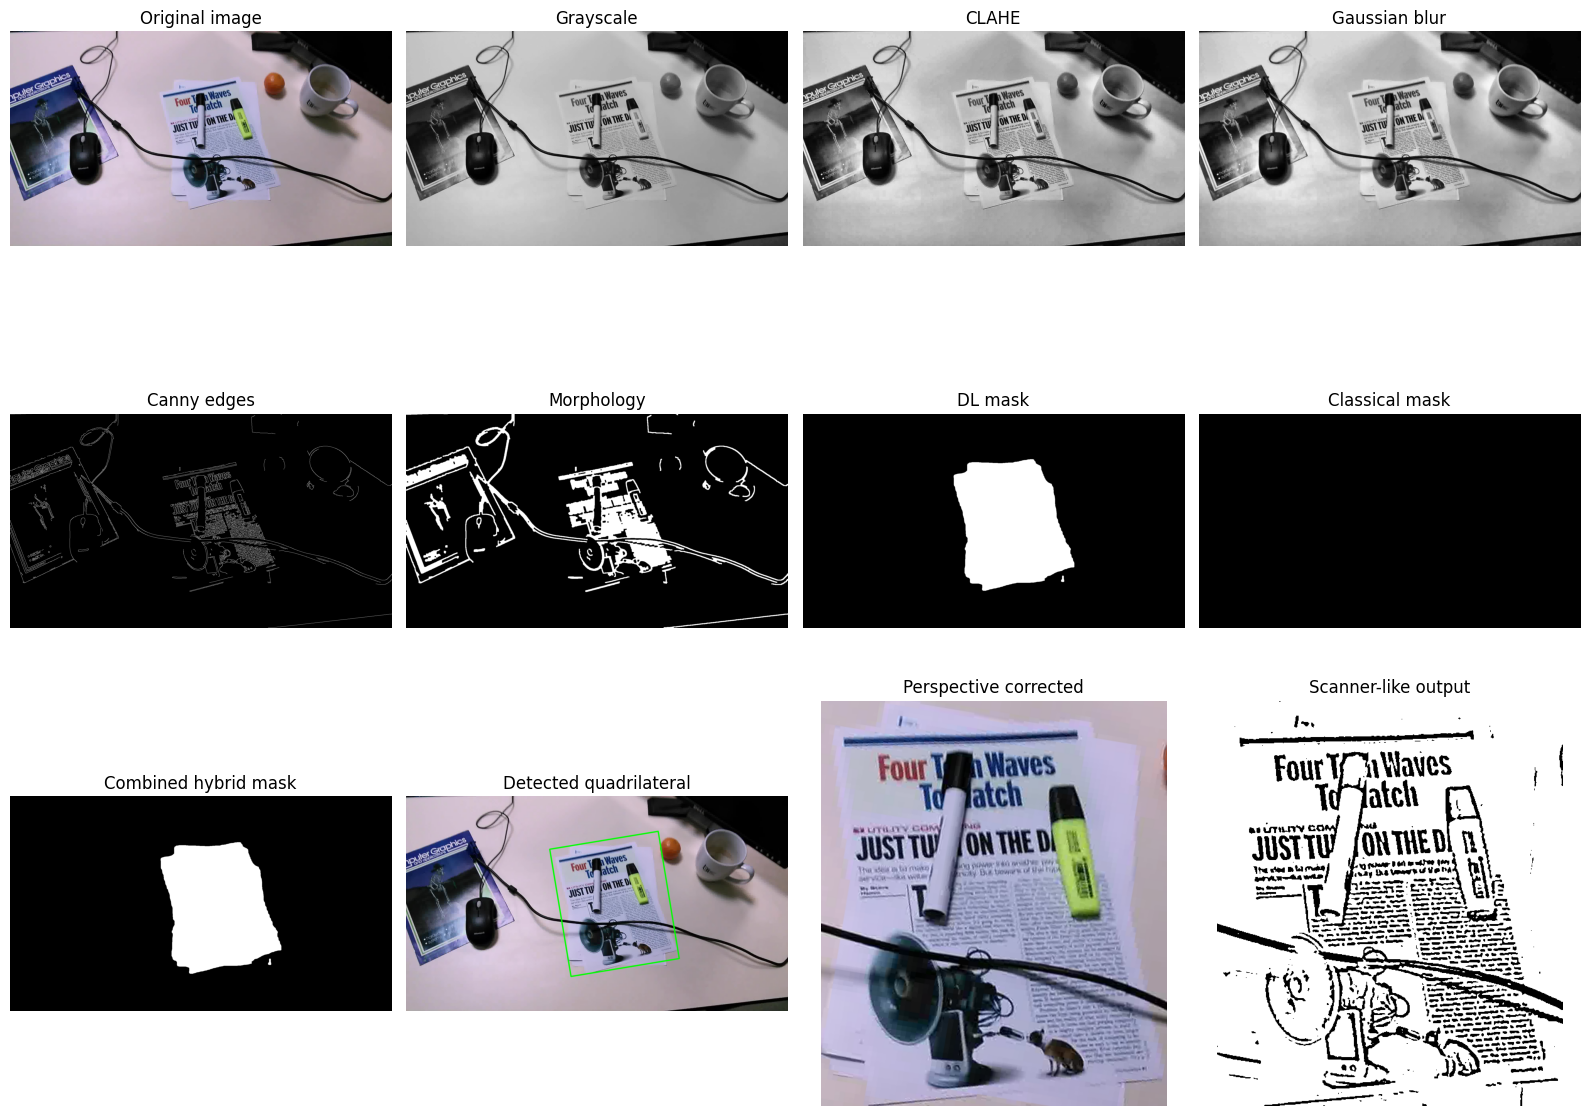

In [12]:
test_row = val_df.sample(1, random_state=SEED).iloc[0]
test_image_path = EXTRACT_DIR / test_row["image_path"]
test_image = read_rgb_image(test_image_path)

results = hybrid_scan(best_model, test_image, IMAGE_SIZE)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes[0, 0].imshow(test_image)
axes[0, 0].set_title("Original image")
axes[0, 0].axis("off")

axes[0, 1].imshow(results["gray"], cmap="gray")
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis("off")

axes[0, 2].imshow(results["clahe"], cmap="gray")
axes[0, 2].set_title("CLAHE")
axes[0, 2].axis("off")

axes[0, 3].imshow(results["blur"], cmap="gray")
axes[0, 3].set_title("Gaussian blur")
axes[0, 3].axis("off")

axes[1, 0].imshow(results["canny"], cmap="gray")
axes[1, 0].set_title("Canny edges")
axes[1, 0].axis("off")

axes[1, 1].imshow(results["morph"], cmap="gray")
axes[1, 1].set_title("Morphology")
axes[1, 1].axis("off")

axes[1, 2].imshow(results["dl_mask"], cmap="gray")
axes[1, 2].set_title("DL mask")
axes[1, 2].axis("off")

axes[1, 3].imshow(results["classical_mask"], cmap="gray")
axes[1, 3].set_title("Classical mask")
axes[1, 3].axis("off")

axes[2, 0].imshow(results["combined_mask"], cmap="gray")
axes[2, 0].set_title("Combined hybrid mask")
axes[2, 0].axis("off")

axes[2, 1].imshow(results["overlay"])
axes[2, 1].set_title("Detected quadrilateral")
axes[2, 1].axis("off")

axes[2, 2].imshow(results["warped"])
axes[2, 2].set_title("Perspective corrected")
axes[2, 2].axis("off")

axes[2, 3].imshow(results["scan"], cmap="gray")
axes[2, 3].set_title("Scanner-like output")
axes[2, 3].axis("off")

plt.tight_layout()
plt.show()

In [13]:
test_name = Path(test_row["image_path"]).stem

cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_gray.jpg"), results["gray"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_clahe.jpg"), results["clahe"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_blur.jpg"), results["blur"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_canny.jpg"), results["canny"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_morph.jpg"), results["morph"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_dl_mask.jpg"), results["dl_mask"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_classical_mask.jpg"), results["classical_mask"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_combined_mask.jpg"), results["combined_mask"])
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_overlay.jpg"), cv2.cvtColor(results["overlay"], cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_warped.jpg"), cv2.cvtColor(results["warped"], cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_ROOT / f"{test_name}_scan.jpg"), results["scan"])

print("Saved outputs into:", OUTPUT_ROOT)

Saved outputs into: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


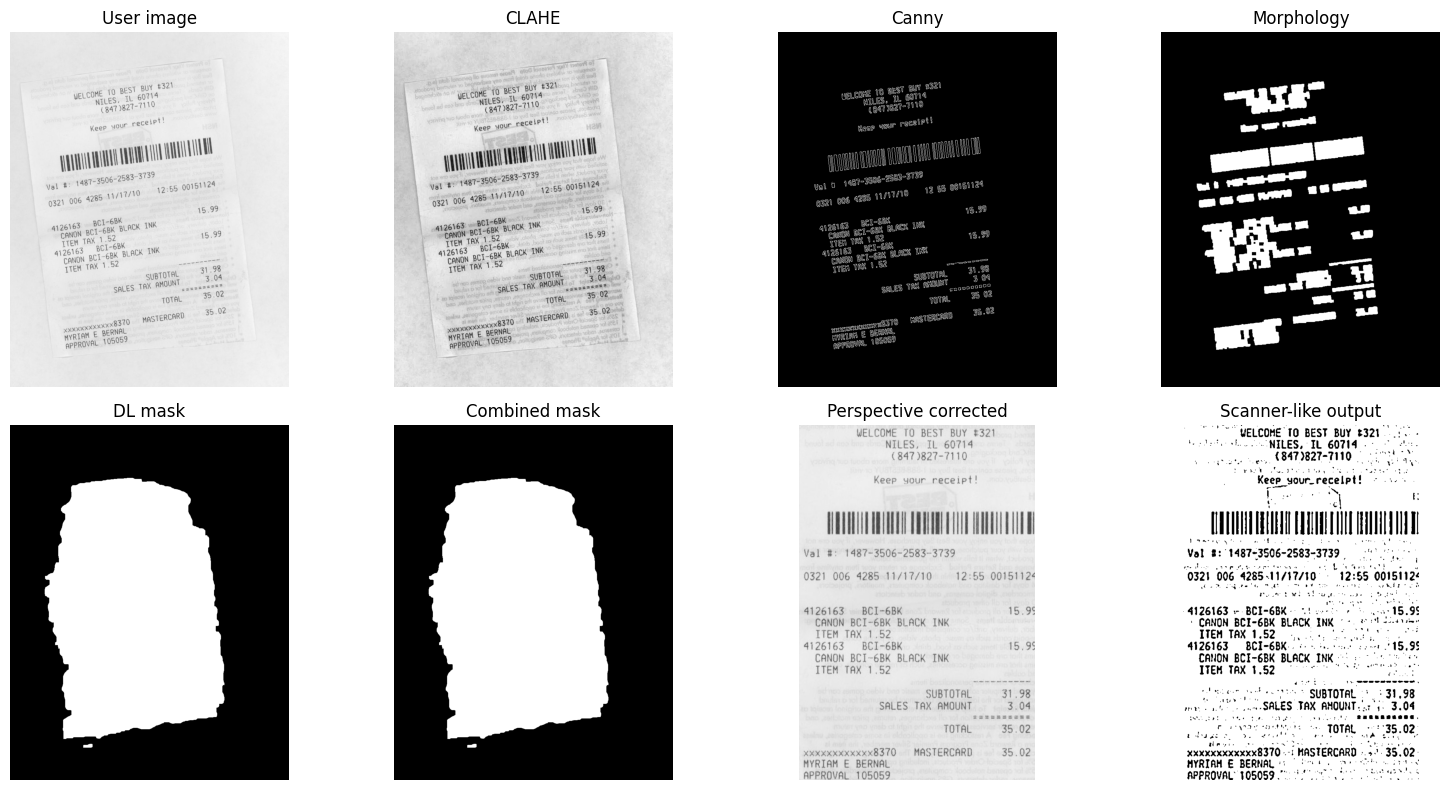

Saved user results inside: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


In [14]:
USER_IMAGE_PATH = "test.jpg"
user_path = Path(USER_IMAGE_PATH)

if user_path.exists():
    user_image = read_rgb_image(user_path)
    user_results = hybrid_scan(best_model, user_image, IMAGE_SIZE)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes[0, 0].imshow(user_image)
    axes[0, 0].set_title("User image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(user_results["clahe"], cmap="gray")
    axes[0, 1].set_title("CLAHE")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(user_results["canny"], cmap="gray")
    axes[0, 2].set_title("Canny")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(user_results["morph"], cmap="gray")
    axes[0, 3].set_title("Morphology")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(user_results["dl_mask"], cmap="gray")
    axes[1, 0].set_title("DL mask")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(user_results["combined_mask"], cmap="gray")
    axes[1, 1].set_title("Combined mask")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(user_results["warped"])
    axes[1, 2].set_title("Perspective corrected")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(user_results["scan"], cmap="gray")
    axes[1, 3].set_title("Scanner-like output")
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

    cv2.imwrite(str(OUTPUT_ROOT / "user_gray.jpg"), user_results["gray"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_clahe.jpg"), user_results["clahe"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_blur.jpg"), user_results["blur"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_canny.jpg"), user_results["canny"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_morph.jpg"), user_results["morph"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_dl_mask.jpg"), user_results["dl_mask"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_classical_mask.jpg"), user_results["classical_mask"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_combined_mask.jpg"), user_results["combined_mask"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_overlay.jpg"), cv2.cvtColor(user_results["overlay"], cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_warped.jpg"), cv2.cvtColor(user_results["warped"], cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_scan.jpg"), user_results["scan"])

    print("Saved user results inside:", OUTPUT_ROOT)
else:
    print("Set USER_IMAGE_PATH to your own image and rerun this cell.")

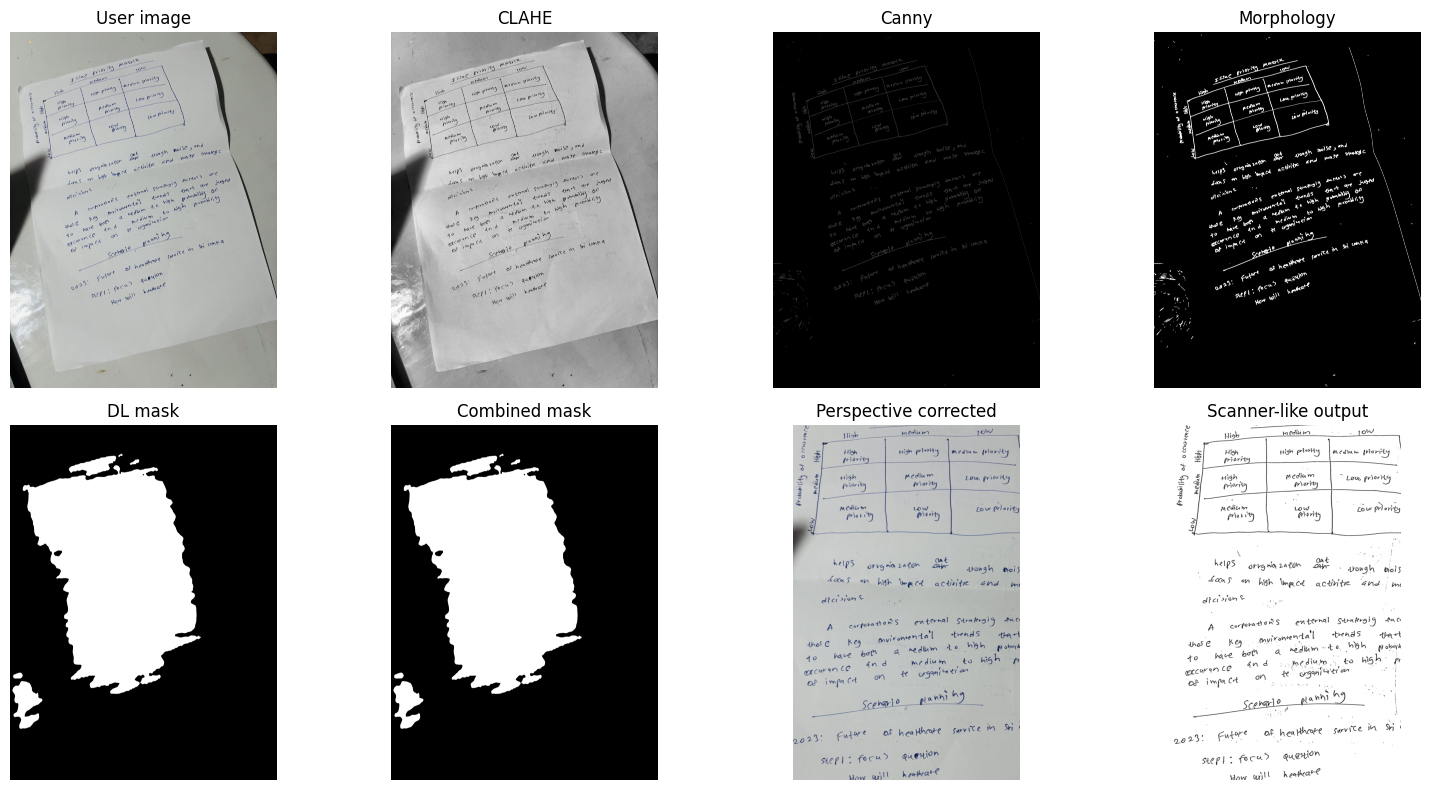

Saved user results inside: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


In [15]:
USER_IMAGE_PATH = "Test4.jpeg"
user_path = Path(USER_IMAGE_PATH)

if user_path.exists():
    user_image = read_rgb_image(user_path)
    user_results = hybrid_scan(best_model, user_image, IMAGE_SIZE)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes[0, 0].imshow(user_image)
    axes[0, 0].set_title("User image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(user_results["clahe"], cmap="gray")
    axes[0, 1].set_title("CLAHE")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(user_results["canny"], cmap="gray")
    axes[0, 2].set_title("Canny")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(user_results["morph"], cmap="gray")
    axes[0, 3].set_title("Morphology")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(user_results["dl_mask"], cmap="gray")
    axes[1, 0].set_title("DL mask")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(user_results["combined_mask"], cmap="gray")
    axes[1, 1].set_title("Combined mask")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(user_results["warped"])
    axes[1, 2].set_title("Perspective corrected")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(user_results["scan"], cmap="gray")
    axes[1, 3].set_title("Scanner-like output")
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

    cv2.imwrite(str(OUTPUT_ROOT / "user_gray.jpg"), user_results["gray"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_clahe.jpg"), user_results["clahe"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_blur.jpg"), user_results["blur"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_canny.jpg"), user_results["canny"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_morph.jpg"), user_results["morph"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_dl_mask.jpg"), user_results["dl_mask"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_classical_mask.jpg"), user_results["classical_mask"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_combined_mask.jpg"), user_results["combined_mask"])
    cv2.imwrite(str(OUTPUT_ROOT / "user_overlay.jpg"), cv2.cvtColor(user_results["overlay"], cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_warped.jpg"), cv2.cvtColor(user_results["warped"], cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_scan.jpg"), user_results["scan"])

    print("Saved user results inside:", OUTPUT_ROOT)
else:
    print("Set USER_IMAGE_PATH to your own image and rerun this cell.")